**Project Overview**
This project analyzes retail transaction data to evaluate sales growth trends and customer purchasing behavior over time. The analysis focuses on identifying category-level growth patterns, seasonal sales dynamics, and customer buying characteristics that could support revenue optimization and strategic planning.

**Key Questions**

* Which product categories experienced the highest and lowest sales growth?
* How do sales and quantity trends vary by month and year?
* What patterns emerge in customer purchasing behavior across stores?

**Approach**

* Data integration across sales, product, date, and category tables
* Aggregation and growth comparison across time periods
* Trend visualization and customer-level summarization

**Tools Used**

Python · Pandas · Matplotlib · Seaborn
  
**Key Insights**
 * Sales growth varies significantly across product categories.
 * Clear seasonal trends are observable in monthly sales performance.
 * Customer purchasing behavior differs meaningfully by store and time period.

In [2]:
import pandas as pd

In [6]:
item_sales = pd.read_parquet('item_sales.parquet')
date = pd.read_csv('d_dates.csv')
items = pd.read_csv('d_items.csv')
categories = pd.read_csv('d_categories.csv')

In [7]:
left_join_df = pd.merge(categories, items, on = 'InventoryCategory', how = 'left')\
  .merge(item_sales, on = 'ItemKey', how = 'left') \
  .merge(date, on = 'DateKey', how = 'left')

In [8]:
#What are the top 3 and bottom 3 categories based on the sells growth in the first half of 2015 compared to that of 2014? (point: 10)
first_half = left_join_df[left_join_df['MonthNum']<= 6]

category_sales = (
    first_half.groupby(['InventoryCategoryLabel', 'YearNum'])['AmountSold']
    .sum()
    .reset_index()
)

# pivot for easier comparison
pivoted = category_sales.pivot(index='InventoryCategoryLabel', columns='YearNum', values='AmountSold').reset_index()

# calculate growth percentage
pivoted['Growth_%'] = ((pivoted[2015] - pivoted[2014]) / pivoted[2014]) * 100
pivoted.head()

top3 = pivoted.nlargest(3, 'Growth_%')[['InventoryCategoryLabel', 'Growth_%']]
bottom3 = pivoted.nsmallest(3, 'Growth_%')[['InventoryCategoryLabel', 'Growth_%']]

print("Top 3 categories by sales growth:")
print(top3)

print("\nBottom 3 categories by sales growth:")
print(bottom3)


Top 3 categories by sales growth:
YearNum    InventoryCategoryLabel   Growth_%
12       22 - GENERAL MERCHANDISE  42.197469
7         17 - ALTERNATIVE SNACKS  14.565097
23                      8 - CANDY  10.468932

Bottom 3 categories by sales growth:
YearNum   InventoryCategoryLabel   Growth_%
15                      28 - ICE -24.958136
14               24 - AUTOMOTIVE -21.039936
10       20 - NON EDIBLE GROCERY -20.804585


In [9]:
item_date = item_sales.merge(date, on ='DateKey', how ='left')
daily_store = (
    item_date.groupby(['StoreKey', 'DateKey', 'YearNum', 'MonthNum'])[['QtySold', 'AmountSold']]
      .sum()
      .reset_index()
)

monthly_avg = (
    daily_store.groupby(['YearNum', 'MonthNum'])[['QtySold', 'AmountSold']]
      .mean()
      .reset_index()
      .rename(columns={
          'QtySold': 'Average Qty Sold',
          'AmountSold': 'Average Amount Sold'
      })
)

monthly_avg.head()
#monthly_avg_overall = (
#    daily_store.groupby('MonthNum')[['QtySold', 'AmountSold']]
#      .mean()
#      .reset_index()
#)
#monthly_avg_overall.head()



,YearNum,MonthNum,Average Qty Sold,Average Amount Sold
0,2014,1,962.870968,2406.696774
1,2014,2,1106.857143,2760.252857
2,2014,3,1158.564516,2878.885484
3,2014,4,1159.433333,2827.793167
4,2014,5,1209.580645,2969.532903


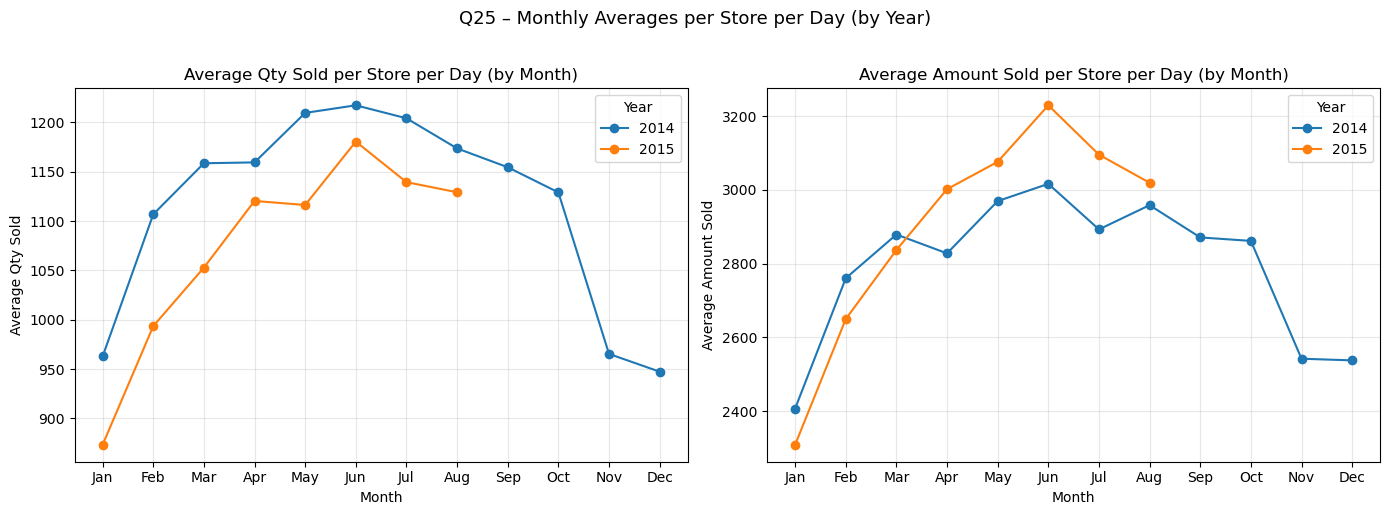

In [10]:
import matplotlib.pyplot as plt
month_labels = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly_avg['Month'] = monthly_avg['MonthNum'].map(month_labels)

# ---------- Q25: plots (two subplots, side-by-side) ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Left: Average Qty Sold
for y in sorted(monthly_avg['YearNum'].unique()):
    d = monthly_avg[monthly_avg['YearNum'] == y]
    axes[0].plot(d['MonthNum'], d['Average Qty Sold'], marker='o', label=str(y))
axes[0].set_title('Average Qty Sold per Store per Day (by Month)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Qty Sold')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels([month_labels[m] for m in range(1,13)], rotation=0)
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Year')

# Right: Average Amount Sold
for y in sorted(monthly_avg['YearNum'].unique()):
    d = monthly_avg[monthly_avg['YearNum'] == y]
    axes[1].plot(d['MonthNum'], d['Average Amount Sold'], marker='o', label=str(y))
axes[1].set_title('Average Amount Sold per Store per Day (by Month)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Amount Sold')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels([month_labels[m] for m in range(1,13)], rotation=0)
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Year')

plt.suptitle('Q25 – Monthly Averages per Store per Day (by Year)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
df = item_sales.merge(date, on='DateKey', how='left') \
                .merge(items, on='ItemKey', how='left')
customer_summary = (
    df.groupby(['StoreKey', 'CustomerKey'])
      .agg(
          UniqueItems=('ItemKey', 'nunique'),     # number of unique items
          TotalItems=('QtySold', 'sum'),          # total items purchased
          TotalAmount=('AmountSold', 'sum')       # total spending
      )
      .reset_index()
)

store_avg = (
    customer_summary.groupby('StoreKey')[['UniqueItems', 'TotalItems', 'TotalAmount']]
      .mean()
      .reset_index()
      .rename(columns={
          'UniqueItems': 'Average # Unique Items',
          'TotalItems': 'Average # Items',
          'TotalAmount': 'Average Amount Spent'
      })
)

store_avg.head()

,StoreKey,Average # Unique Items,Average # Items,Average Amount Spent
0,125,1.843302,2.149929,4.824262
1,150,1.650018,1.928479,5.499094


In [12]:
df = item_sales.merge(date, on='DateKey', how='left') \
                .merge(items, on='ItemKey', how='left')

customer_unique_items = (
    df.groupby('CustomerKey')['ItemKey']
      .nunique()
      .reset_index(name='UniqueItems')
)

counts = (
    customer_unique_items['UniqueItems']
      .value_counts()
      .reset_index()
      .rename(columns={'index': 'UniqueItems', 'UniqueItems': 'CustomerCount'})
     # .sort_values('UniqueItems')
)

total_customers = counts['CustomerCount'].sum()
counts['Percentage'] = (counts['CustomerCount'] / total_customers) * 100

top5 = counts.sort_values('Percentage', ascending=False).head(5)
top5


,CustomerCount,count,Percentage
27,54,1,12.244898
25,31,1,7.029478
23,29,2,6.575964
26,27,1,6.122449
22,24,3,5.442177
